In [ ]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
from torch.optim import AdamW
from torch.amp import autocast, GradScaler
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
pin_memory = device.type == "cuda"
print(f"Using device: {device}")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

if device.type == "cuda":
    # Speed up convolutions for fixed-size inputs
    torch.backends.cudnn.benchmark = True

Using device: cuda


In [ ]:
from datasets import load_dataset
from datasets import Image

ds = load_dataset("Sandesh-Lav/8k_potato-tuber-caption-dataset")
ds = ds.cast_column("image", Image())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/592 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/55 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/55 [00:00<?, ?it/s]

data/train-00000-of-00055.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

...

data/test-00003-of-00004.parquet:   0%|          | 0.00/369M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/36072 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2004 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2004 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/51 [00:00<?, ?it/s]

In [ ]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'caption'],
        num_rows: 36072
    })
    validation: Dataset({
        features: ['image', 'caption'],
        num_rows: 2004
    })
    test: Dataset({
        features: ['image', 'caption'],
        num_rows: 2004
    })
})


In [ ]:
print(ds["train"].features)

{'image': Image(mode=None, decode=True), 'caption': Value('string')}


In [ ]:
sample = ds["train"][0]

print(sample)

{'image': <PIL.Image.Image image mode=RGB size=1182x1407 at 0x7AB08FB03500>, 'caption': 'A whole potato tuber sample with severe dense brown scab lesions covering most of the surface.'}


## Configuration

In [ ]:
# --- Configuration ---
MODEL_NAME = "Salesforce/blip-image-captioning-base"

EPOCHS = 3
BATCH_SIZE = 64
LEARNING_RATE = 5e-5
MAX_LENGTH = 32
NUM_WORKERS = 0

SEED = 41

## Load Data & Processor

In [ ]:
# Load BLIP processor
#it is used to preprocess the images and captions for the BLIP model.
# It handles tasks like resizing, normalization, and tokenization, ensuring that the inputs are
# in the correct format for the model.
processor = BlipProcessor.from_pretrained(MODEL_NAME)
print("Processor loaded.")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Processor loaded.


## Train/Validation Split & DataLoaders

In [ ]:
train_ds = ds["train"]
val_ds = ds["validation"]
test_ds = ds["test"]
print(train_ds[0])

{'image': <PIL.Image.Image image mode=RGB size=1182x1407 at 0x7AB08C320800>, 'caption': 'A whole potato tuber sample with severe dense brown scab lesions covering most of the surface.'}


In [ ]:
import torch
from torchvision.transforms import InterpolationMode

# Dataset info
print(f"Train samples: {len(train_ds)}")
print(f"Val samples:   {len(val_ds)}")
print(f"Test samples:  {len(test_ds)}")

# DataLoader config
loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
}

# if NUM_WORKERS > 0:
#     loader_kwargs["persistent_workers"] = True
#     loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

print(
    f"DataLoader config | num_workers={NUM_WORKERS} | "
    f"pin_memory={pin_memory} | "
    f"persistent_workers={loader_kwargs.get('persistent_workers', False)}"
)

# Lazy transform (replace tokenize_captions + map) because of memory constraints
def transform_example(example):

    # ---------- IMAGE PROCESSING ----------
    images = example["image"]
    if not isinstance(images, list):
        images = [images]

    images = [img.convert("RGB") for img in images]

    pixel_values = processor.image_processor(
        images=images,
        return_tensors="pt"
    )["pixel_values"]

    #  TOKENIZATION (same as tokenize_captions) 
    tokenized = processor.tokenizer(
        example["caption"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    input_ids = tokenized["input_ids"]
    attention_mask = tokenized["attention_mask"]

    # Replace PAD tokens with -100 for loss masking
    labels = input_ids.clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100

    return {
        "pixel_values": pixel_values,
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }

# Attach lazy transforms
train_ds.set_transform(transform_example)
val_ds.set_transform(transform_example)
test_ds.set_transform(transform_example)


Train samples: 36072
Val samples:   2004
Test samples:  2004
DataLoader config | num_workers=0 | pin_memory=True | persistent_workers=False


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)

In [ ]:
for batch in train_loader:
    print(batch.keys())
    break

dict_keys(['pixel_values', 'input_ids', 'attention_mask', 'labels'])


## Load Model

In [ ]:
model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME)
model.to(device)
model = model.to(memory_format=torch.channels_last)
#trying gradient checkpointing to fit larger effective batch size on GPU
# model.gradient_checkpointing_enable()
model.config.use_cache = False
# Freeze vision encoder to save memory & speed up training (only train text decoder)
for param in model.vision_model.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Trainable parameters: 161,354,104 / 247,444,600 (65.2%)


## Training Loop

In [ ]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(params, lr=LEARNING_RATE)
scaler = GradScaler("cuda", enabled=use_amp)
model.config.use_cache = False

train_losses = []
val_losses = []

# trying gradient accumulation to fit larger effective batch size on GPU
accum_steps = 4
model.config.use_cache = False
model.config.output_attentions = False
model.config.output_hidden_states = False
autocast_ctx = torch.autocast(device_type="cuda", dtype=torch.float16)
# disable vision gradients
model.vision_model.eval()

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    epoch_train_loss = 0.0
    optimizer.zero_grad(set_to_none=True)
    for batch_idx, batch in enumerate(train_loader):
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        pixel_values = batch["pixel_values"].to(
            device, memory_format=torch.channels_last, non_blocking=pin_memory
        )
        input_ids = batch["input_ids"].to(device, non_blocking=pin_memory)
        labels = batch["labels"].to(device, non_blocking=pin_memory)

        # optimizer.zero_grad(set_to_none=True)

        with autocast_ctx:
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                labels=labels,
                attention_mask=attention_mask,
            )
            loss = outputs.loss / accum_steps

        scaler.scale(loss).backward()
        if (batch_idx + 1) % accum_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        # scaler.scale(loss).backward()
        # scaler.step(optimizer)
        # scaler.update()

        epoch_train_loss += loss.detach()

        if (batch_idx + 1) % 10 == 0:
            print(
                f"  Epoch {epoch+1}/{EPOCHS} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}"
            )
    #step for batches not divisible by accum_steps
    if len(train_loader) % accum_steps != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    avg_train_loss = epoch_train_loss.item() / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model.eval()
    epoch_val_loss = 0.0

    with torch.inference_mode():
        for batch in val_loader:
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)
            pixel_values = batch["pixel_values"].to(
                device, memory_format=torch.channels_last, non_blocking=pin_memory
            )
            input_ids = batch["input_ids"].to(device, non_blocking=pin_memory)
            labels = batch["labels"].to(device, non_blocking=pin_memory)

            with autocast_ctx:
                outputs = model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,
                    labels=labels,
                    attention_mask=attention_mask,
                )
            epoch_val_loss += outputs.loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} — Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}"
    )

model.config.use_cache = True
print("\nTraining complete!")

## Loss Curves

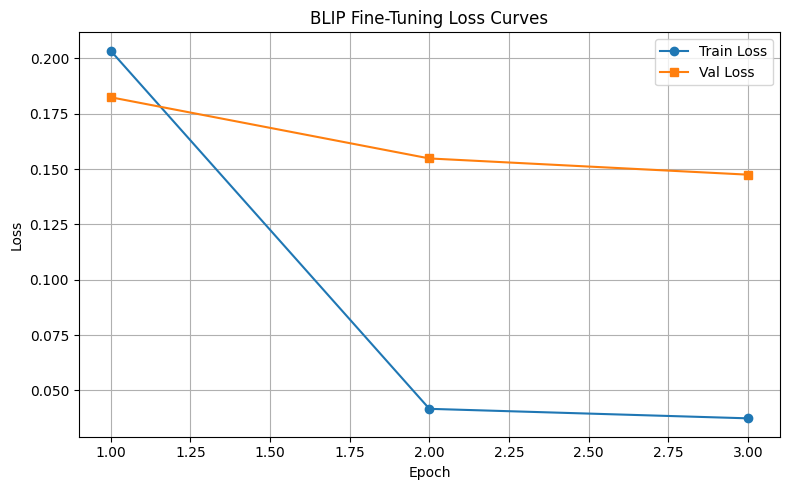

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, marker="s", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BLIP Fine-Tuning Loss Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
!pip install pycocoevalcap evaluate rouge_score

In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from pycocoevalcap.cider.cider import Cider
import nltk
import evaluate

try:

    nltk.data.find("tokenizers/punkt")

except LookupError:

    nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
#save the model
model.save_pretrained('/content/model')
processor.save_pretrained('/content/model')
print(f"Model and processor saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and processor saved.


In [ ]:
!export PYTORCH_ALLOC_CONF=expandable_segments:True

In [ ]:
import gc

try:
    model.to("cpu")
except:
    pass

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print("GPU memory cleared.")

GPU memory cleared.


In [ ]:
# Load standardized Hugging Face metrics
model.eval()
bleu_metric = evaluate.load("bleu")
meteor_metric = evaluate.load("meteor")
rouge_metric = evaluate.load("rouge")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
import torch
from transformers import BlipForConditionalGeneration, BlipProcessor
MODEL_PATH = "/content/model"

processor = BlipProcessor.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BlipForConditionalGeneration.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
)

model.to(device)
model.eval()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [ ]:
# Initialize CIDEr
cider_scorer = Cider()
model.eval()

predictions = []
references = []
gts = {}
res = {}

idx = 0  # Global index for CIDEr formatting

# with torch.no_grad():
with torch.inference_mode():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].clone()
        labels[labels == -100] = processor.tokenizer.pad_token_id

        # Generate captions
        generated_ids = model.generate(
            pixel_values=pixel_values,
            max_new_tokens=32,
            num_beams=2,
        )

        # Decode predictions and references
        preds = processor.batch_decode(generated_ids, skip_special_tokens=True)
        refs = processor.tokenizer.batch_decode(labels, skip_special_tokens=True)

        # Process and format outputs in a single pass
        for pred, ref in zip(preds, refs):
            clean_pred = pred.strip()
            clean_ref = ref.strip()

            predictions.append(clean_pred)
            references.append(clean_ref)

            # Format dictionaries for CIDEr directly
            res[idx] = [clean_pred]
            gts[idx] = [clean_ref]
            idx += 1

# Compute standard metrics
bleu_result = bleu_metric.compute(predictions=predictions, references=[[ref] for ref in references])
meteor_result = meteor_metric.compute(predictions=predictions, references=references)
rouge_result = rouge_metric.compute(predictions=predictions, references=references)
cider_score, _ = cider_scorer.compute_score(gts, res)

print("Testing Caption Metrics")
print(f"BLEU: {bleu_result['bleu']:.4f}")
print(f"METEOR: {meteor_result['meteor']:.4f}")
print(f"CIDEr: {cider_score:.4f}")
print(f"ROUGE-L: {rouge_result['rougeL']:.4f}")

# Store results in DataFrame
results_df = pd.DataFrame(
    {
        "reference": references,
        "prediction": predictions,
    }
)

results_df.head(10)

Validation Caption Metrics
BLEU: 0.2182
METEOR: 0.3978
CIDEr: 1.4458
ROUGE-L: 0.3635


,reference,prediction
0,a potato tuber sample with moderate greening n...,a cut potato tuber showing moderate potato tub...
1,extensive moist necrotic regions covering the ...,severe - stage soft rot characterized by wides...
2,a whole potato tuber exhibiting moderate black...,a whole potato tuber exhibiting moderate dry r...
3,a cut tuber displaying localized mild desiccat...,a cut - section of a potato tuber showing mild...
4,a whole potato tuber displaying mild irregular...,a whole potato tuber exhibiting severe dry rot...
5,a whole potato tuber exhibiting normal physiol...,a whole potato tuber exhibiting normal physiol...
6,a whole potato tuber displaying severe pronoun...,a whole potato tuber displaying moderate super...
7,a longitudinal cut view of a potato tuber exhi...,"a sliced potato tuber displaying moderate dry,..."
8,an internal cross - section of a potato tuber ...,a cut - section of a potato tuber showing mode...
9,"a sliced potato tuber displaying severe dry, d...",an internal cross - section of a potato tuber ...
